## Plot Precipitation climatological daily cumulative sum

In [32]:
#%load_ext autoreload
#%autoreload 2
#%matplotlib inline

import xarray as xr
import matplotlib.pyplot as mp
import pandas as pd
#import geocat.comp as gc
#import seaborn as sb
import scipy as sp

import numpy as np
import os
import glob as gb
import dask

from matplotlib.cm import get_cmap
from matplotlib.dates import DateFormatter,MonthLocator
from matplotlib import cm
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cf
from cartopy.io import shapereader
import geopandas


# Import
import importlib

### To Import My Functions ###
import daily_annual_cycle_calc as myplt

#import intake 
from distributed import Client
from dask_jobqueue import PBSCluster

In [33]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37815 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/37815/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/37815/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.68:35223,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/37815/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [40]:
'''
    SET UP CASE
'''

reg_name = 'AIR'

#case_names = ['GPCP','TRMM','CESM2','CESM3-125']
#case_names = ['AIR','GPCP','TRMM','CESM2']
#case_names = ['CAM7-L58','CESM3-127','CESM3-104','CESM3-98','CESM3-93','CESM3-82b','CESM2','TRMM','GPCP']
case_names = ['CAM7-L58','CESM3-271','CESM2','TRMM','GPCP']
#case_names = ['AIR','GPCP','TRMM','CMIP5']



var_name = 'PRECT' ; vscale = 86400.*1000.
years = ['1979','2005']
lpsave = True


fig_name = 'Onset_AMWG2025_test'

# For the time/lat monsoon plot.FGOALS-g2_dmeans_ts_PRECT.nc
#lonm_w = 70 ; lonm_e = 100.
#latm_s = 0.; latm_n = 40. 





# Border of region for displaying map.
moffset = 10.




# Some run names
crnums = ['001','002','003','004','005','006','007','008','009','010']
#crnums = ['001','002','003','004','005']
#crnums = ['001']

#ernums =  ['0101','0151','0201','0251','0301']
ernums =  ['0101']

c5rnames = ['MIROC5','MPI-ESM-LR','ACCESS1-0','CESM1','CCSM4','NorESM1-M','FGOALS-g2']

## NOTES ##
# Good: ACCESS1-0, CanAM4, CESM1, CCSM4, NorESM, FGGOALS-g2,
# CESM1 is 1850 and has days since 0001-01-01
# EC-EARTH, bcc-csm1-1, CNRM-CM5, GFDL-CM3 has 366 days not 365 days per year.
# IPSL-CM5A-LR doy dimenstion 359???

### Regions ###

if reg_name == 'India':
    lonm_w = 70 ; lonm_e = 85.
    latm_s = 10.; latm_n = 35. 

if reg_name == 'W_Ind_Ocean':
    lonm_w = 52 ; lonm_e = 65.
    latm_s = -8.; latm_n = 5. 

if reg_name == 'AIR': # The rectilinear region but not the averaginng region.
    lonm_w = 72. ; lonm_e = 88.
    latm_s = 10. ; latm_n = 30. 

# Annual cycle options.
lat_lon = lonm_w,lonm_e,latm_s,latm_n,reg_name

print(lat_lon)

(72.0, 88.0, 10.0, 30.0, 'AIR')


In [41]:
## Directories

dir_obs = '/glade/cesm/amwg/amwg_data/obs_data/'
dir_e3sm = '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/'
dir_cesm2 = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'
dir_cesm1 = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily'
dir_scratch = '/glade/derecho/scratch/rneale/'

dir_o = '/glade/work/rneale/data/'


'''
    Ensmble set dic
'''

# Set ensembles set dic and df.

rset_dic = {}
rset_dic['CMIP5'] = [dir_scratch+'CMIP5', c5rnames,'',years,'g','-',1.5]
rset_dic['E3SMv2'] = [dir_e3sm, ernums,'v2.FV1.historical_',years,'b','-',1.5]
rset_dic['E3SM'] = [dir_e3sm, ernums,'v2.FV1.historical_',years,'b','-',1.5]
rset_dic['CESM2'] =  [dir_cesm2,crnums,'b.e21.BHISTcmip6.f09_g17.LE2-1251.',years,'k','-',1.5]
rset_dic['CESM1'] =  [dir_cesm1,crnums,'b.e11.B20TRC5CNBDRD.f09_g16.',years,'r','-',1.5]

rset_dic['GPCP'] =  [dir_o,[''],'GPCP',years,'k','--',4]
rset_dic['TRMM'] =  [dir_o,[''],'TRMM',["2000","2009"],'k',':',4]
rset_dic['AIR'] =  [dir_o,[''],'AIR',years,'k','-.',4]

# Single runs of CAM7 or CESM3

rset_dic['CAM7-L58-old'] =  [dir_scratch,[''],'f.e30_cam6_4_036.FLTHIST.ne30_L58.001',years,'b','--',3]
rset_dic['CAM7-L58']     =  [dir_scratch+'archive/',[''],'f.cam6_4_130.FLTHIST_ne30.cam7-dcycle.001',years,'b','--',3]

rset_dic['CESM3-127'] =  [dir_scratch+'archive/',[''],'b.e30_beta05.BLT1850.ne30_t232_wgx3.127',years,'b','-',3]
rset_dic['CESM3-112'] =  [dir_scratch,[''],'b.e30_alpha03d.BLT1850.ne30_t232_wgx3.112',years,'b','-',3]
rset_dic['CESM3-104'] =  [dir_scratch,[''],'b.e30_beta02.BLT1850.ne30_t232.104',years,'r','-',3]
rset_dic['CESM3-98'] =  [dir_scratch,[''],'b.e23_alpha17f.BLT1850.ne30_t232.098',years,'m','-',3]
rset_dic['CESM3-93'] =  [dir_scratch,[''],'b.e23_alpha17f.BLT1850.ne30_t232.093',years,'c','-',3]
rset_dic['CESM3-82b'] =  [dir_scratch,[''],'b.e23_alpha16g.BLT1850.ne30_t232.082b',years,'g','-',3]
rset_dic['CESM3-156'] =  [dir_scratch+'archive/', [''],'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156',years,'g','-',3]

rset_dic['CESM3-271'] =  [dir_scratch+'archive/', [''],'b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.271',years,'r','-',3]
rset_dic['CESM3-276'] =  [dir_scratch+'archive/', [''],'b.e30_alpha07g.BHISTC_LTso.ne30_t232_wgx3.276',years,'b','-',3]

#Dataframe
# P_all is plot all lines separately in an ensemble and not an ensemble mean, otherwsie it is the e-mean line color.

rset_df = pd.DataFrame.from_dict(rset_dic, orient='index',
            columns=['ens_dir','ens_rnums','ens_pref','ens_years','p_linecol','p_ldash','p_lthick'])

leg_cols = rset_df.loc[case_names]['p_linecol'] 
leg_dash = rset_df.loc[case_names]['p_ldash'] 
#leg_lwidth =  rset_df.loc[case_names]['p_lthick']                  
leg_lines = [Line2D([0], [0], color=col, linewidth=4, linestyle=leg_dash[ic]) for ic,col in enumerate(leg_cols)]


'''
    Variable dic.     
'''

var_dic = {}
var_dic['PRECT'] = (vscale,lat_lon,['GPCP','TRMM','AIR'],['PREC','PRECT',''],[1.,1.,1.])
                          
# Dataframe                                                    
var_df = pd.DataFrame.from_dict(var_dic, orient='index', columns=['vscale','lon_lat','osource','onames','oscale'])                 

scolors = ['black','black','black','black','lightblue','lightgreen','lightcoral']

/glade/derecho/scratch/rneale/tmp/ipykernel_41534/3820901100.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  leg_lines = [Line2D([0], [0], color=col, linewidth=4, linestyle=leg_dash[ic]) for ic,col in enumerate(leg_cols)]


/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:180: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)


 ---------- Variable = PRECT -----------

**************************************************************
* Ensemble set # 1  ( CAM7-L58 ) -  1  ensemble simulations
* Asking for years  2001  to  2025
**************************************************************
CAM7-L58  -  1  ensemble members

- Ensemble run #  1
-- return_common_loc -- : Grabbing typical run path for CAM7-L58
/glade/derecho/scratch/rneale/archive//f.cam6_4_130.FLTHIST_ne30.cam7-dcycle.001/tseries/f.cam6_4_130.FLTHIST_ne30.cam7-dcycle.001_clim_dmeans_ts_PRECT.nc
-Dataset year Range = 19XX to 20XX
<xarray.DataArray 'PRECT' (dayofyear: 365)> Size: 3kB
dask.array<mean_agg-aggregate, shape=(365,), dtype=float64, chunksize=(365,), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear  (dayofyear) object 3kB 0001-01-02 00:00:00 ... 0002-01-01 00:0...


**************************************************************
* Ensemble set # 2  ( CESM3-271 ) -  1  ensemble simulations
* Asking for years  2001  to  2025
****************

/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:180: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)



**************************************************************
* Ensemble set # 3  ( CESM2 ) -  10  ensemble simulations
* Asking for years  2001  to  2025
**************************************************************
CESM2  -  10  ensemble members

- Ensemble run #  1
-- return_common_loc -- : Grabbing typical run path for CESM2
-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1850)
Coordinates:
    time     object 8B 1850-01-01 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds  to  <xarray.DataArray 'year' (time: 60226)> Size: 482kB
array([1850, 1850, 1850, ..., 2014, 2014, 2015], shape=(60226,))
Coordinates:
  * time     (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds
Mask Generated for  CESM2
<xarray.DataArray 'PRECT' (time: 5111)> Size: 41kB
dask.array<mean_agg-aggregate, shape=(5111,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (t

/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:206: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dset = xr.open_mfdataset(run_names)


-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1998)
Coordinates:
    time     datetime64[ns] 8B 1998-01-01
Attributes:
    info:     refers to the 00Z for the day  to  <xarray.DataArray 'year' (time: 4383)> Size: 35kB
array([1998, 1998, 1998, ..., 2009, 2009, 2009], shape=(4383,))
Coordinates:
  * time     (time) datetime64[ns] 35kB 1998-01-01 1998-01-02 ... 2009-12-31
Attributes:
    info:     refers to the 00Z for the day
Mask Generated for  TRMM
<xarray.DataArray 'PRECT' (time: 3653)> Size: 15kB
dask.array<mean_agg-aggregate, shape=(3653,), dtype=float32, chunksize=(3653,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 29kB 2000-01-01 2000-01-02 ... 2009-12-31


**************************************************************
* Ensemble set # 5  ( GPCP ) -  1  ensemble simulations
* Asking for years  2001  to  2025
**************************************************************
GPCP  -  1  ensemble members

- Ensemble run #  1
-- return_c

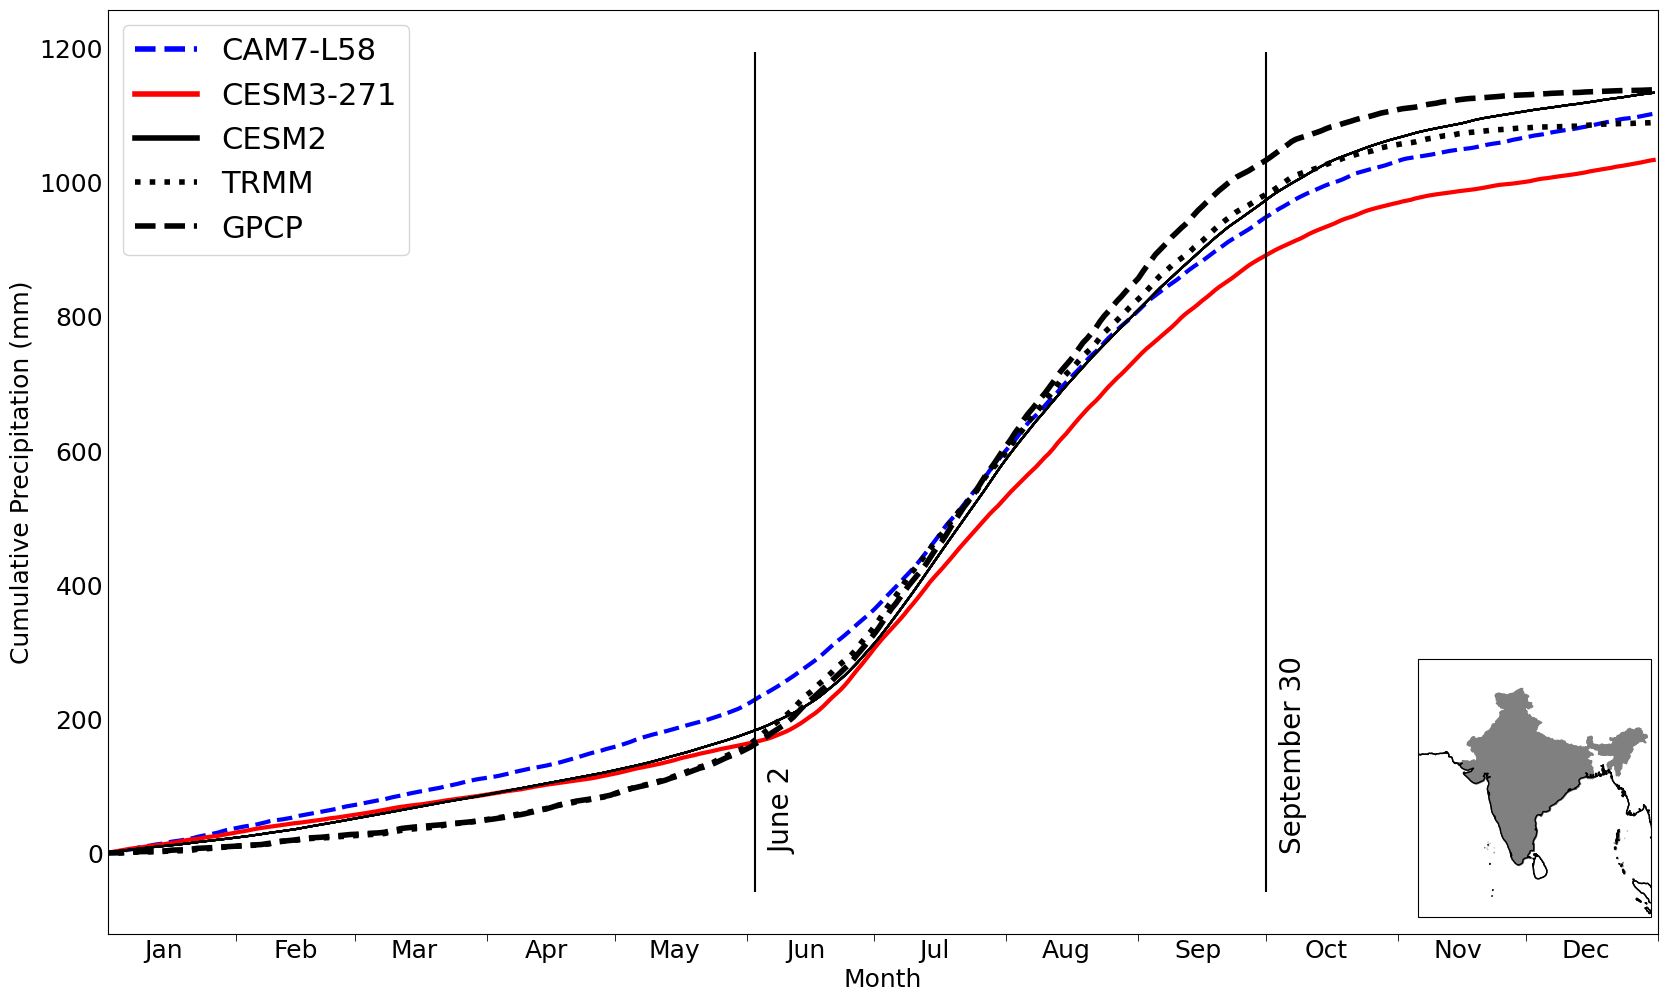

In [43]:
importlib.reload(myplt) # Required because I am constantly editing scam_func.py

fig, ax = mp.subplots(figsize=(20,12))

# Plot the inset of the high resolution India mask
axins = myplt.region_mask(ax,lat_lon,lmask=True)

#land_10m = NaturalEarthFeature('physical', 'land', '10m')


print(' ---------- Variable = '+var_name+' -----------')

for icase,cname in enumerate(case_names):
    
    nens = len(rset_df.loc[cname]['ens_rnums']) # Num. Ensmble simulations
    
    print('')
    print('**************************************************************')
    print('* Ensemble set #',icase+1,' (',cname,') - ',nens,' ensemble simulations')
    print('* Asking for years ',years[0],' to ',years[1])
    print('**************************************************************')
          
    rset = rset_df.loc[cname]   
    
        
    '''
        Routine for reading in data and calculating annual cycle from daily data
    '''
    
    var_data = myplt.calc_daily_acycle(reg_name,cname,rset_df,var_df) # rest dic and ens index   

    
    '''
        Line plotting 
    '''

    # Important options is whether to plot ensembles individually or as lines
    
    linecol = rset_df.loc[cname]['p_linecol']    
    ldash = rset_df.loc[cname]['p_ldash']    
    lthick = rset_df.loc[cname]['p_lthick']    
    porder = 5 if cname in var_df.loc[var_name]['osource'] else 1
    
       
    #%time for iens in range(0,nens) : ax.plot(var_data[iens,:],color=linecol,linestyle=ldash,linewidth=lthick,zorder=porder)
  
    for iens in range(0,nens) : ax.plot(var_data.mean(dim="ens_num"),color=linecol,linestyle=ldash,linewidth=lthick,zorder=porder)

    if nens != 1 and linecol != 'all': 
        print(scolors[icase])
        ax.fill_between(var_data.dayofyear, var_data.min(dim="ens_num"), var_data.max(dim="ens_num"), color=scolors[icase], alpha=.2)

    
'''
    Set Axes And Legend
'''

date_form = DateFormatter("%b")

ax.xaxis.set_major_locator(MonthLocator(bymonthday=15))
ax.xaxis.set_minor_locator(MonthLocator())
ax.xaxis.set_major_formatter(date_form)

ax.set_xlim([1,365]) 
yr = ax.get_ylim()
ax.vlines(153, yr[0], yr[1], color='black', linestyle='-') # Jun 2
ax.vlines(273, yr[0], yr[1], color='black', linestyle='-') # Spe 30

ax.text(156, 0, "June 2", rotation=90, verticalalignment='bottom',fontsize=20)
ax.text(276, 0, "September 30", rotation=90, verticalalignment='bottom',fontsize=20)

ax.tick_params(which='major', length=0)
ax.tick_params(which='minor', length=5)
ax.set_xlabel('Month', fontsize=18)
ax.set_ylabel('Cumulative Precipitation (mm)', fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)




ax.legend(leg_lines, case_names,loc='upper left',fontsize=22)
mp.savefig(fig_name+'_daily_prect_cdf_'+reg_name+'.png', dpi=70)  
    